In [1]:
import random, time
import jax
import jax.numpy as jnp
import numpy as np
from flax.training import checkpoints
from matplotlib import pyplot as plt

from diffusion_linking.jax.circles import generate_circles
from diffusion_linking.jax.schedule import LinearSchedule
from diffusion_linking.jax.diffusion import VariationalDiffusion
from diffusion_linking.jax.smc_clustering import SMCClusterer, resample_optimal, resample_multinomial

In [2]:
checkpoint_path = 'checkpoints'
rng = jax.random.PRNGKey(1)
schedule = LinearSchedule()
model = VariationalDiffusion(rng, dim=2, depth=12, schedule=schedule)

raw_restored = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
model.params = {'params':raw_restored['model']['params']}
model.compile_net()

Dataset to cluster.

(-3.263301658630371,
 0.15539531707763674,
 -4.083533406257629,
 5.0101295709609985)

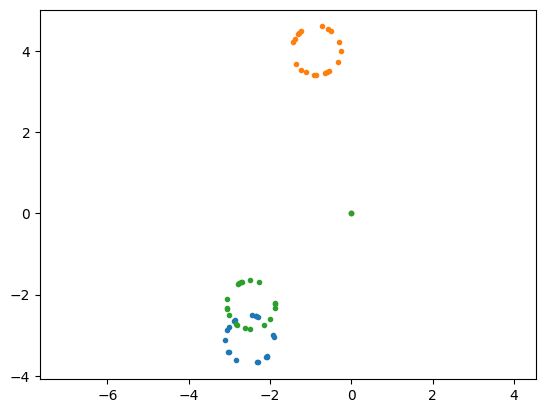

In [3]:
rng = jax.random.PRNGKey(11)
circles_valid, masks_valid = generate_circles(rng, 3, min_points=19, max_points=20, min_radius=0.6, max_radius=0.6)
for cc in circles_valid:
    plt.plot(cc[:, 0], cc[:, 1], 'o', markersize=3)
plt.axis('equal')

In [4]:
cluster_data = []
for k, (c, m) in enumerate(zip(circles_valid, masks_valid)):
    for ci, mi in zip(c, m):
        if mi:
            cluster_data.append(ci[None,:])
            
random.seed(0)
random.shuffle(cluster_data)

Cluster the test dataset, plot clusterings with greatest weights.

  5%|█▋                             | 3/56 [00:07<01:41,  1.92s/it, Particles=5]

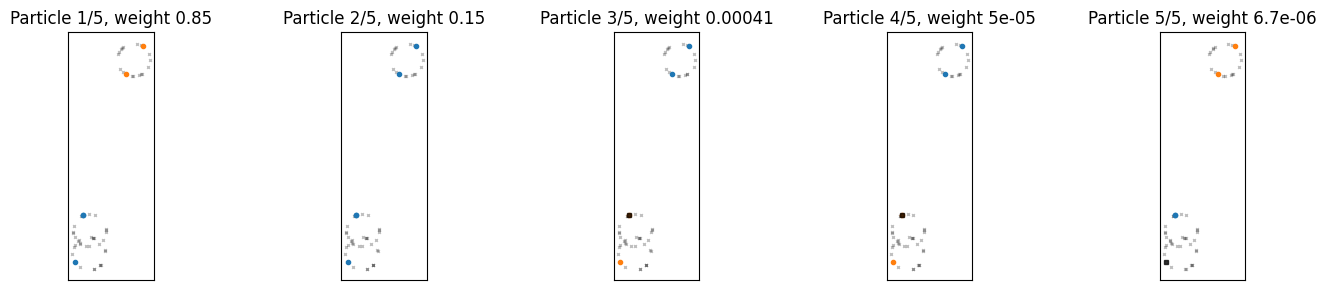

 14%|████▍                          | 8/56 [00:17<01:43,  2.16s/it, Particles=5]

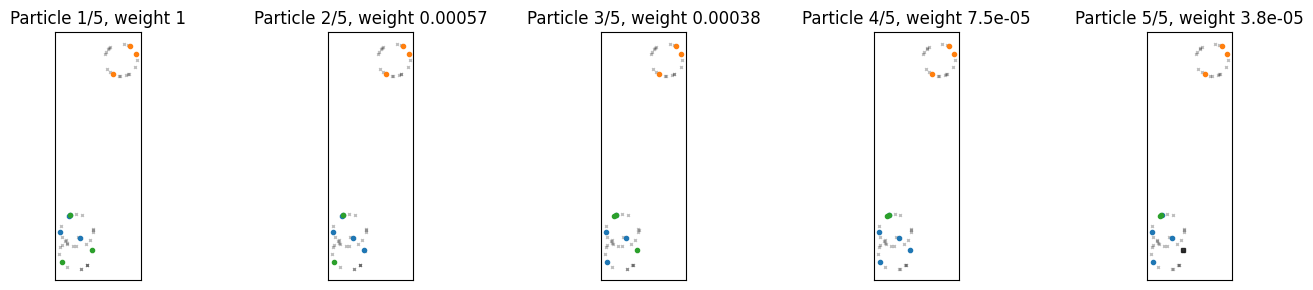

 23%|██████▉                       | 13/56 [00:26<01:18,  1.82s/it, Particles=5]

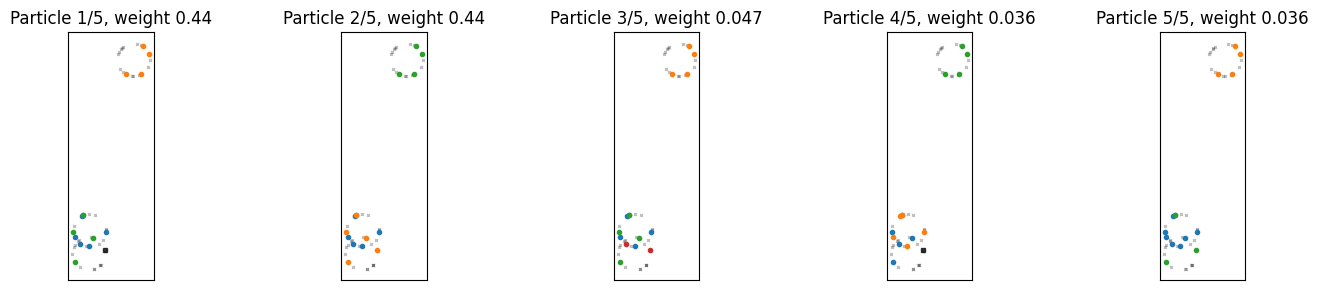

 32%|█████████▋                    | 18/56 [00:35<01:04,  1.70s/it, Particles=5]

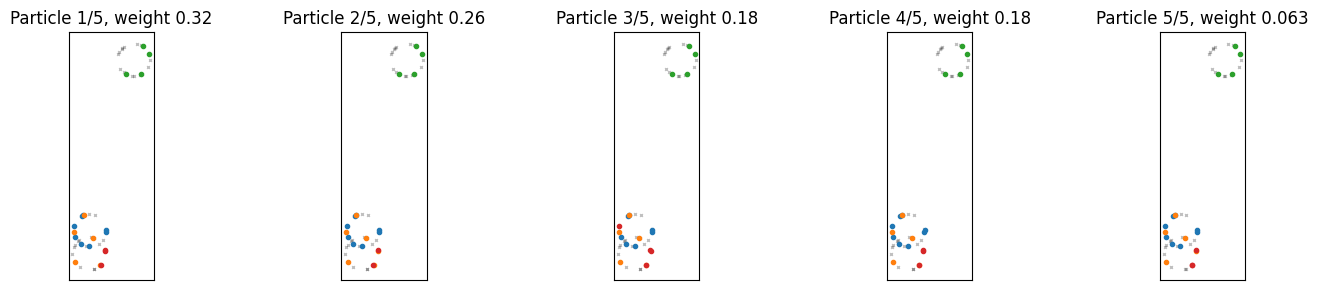

 41%|████████████▎                 | 23/56 [00:43<00:52,  1.58s/it, Particles=5]

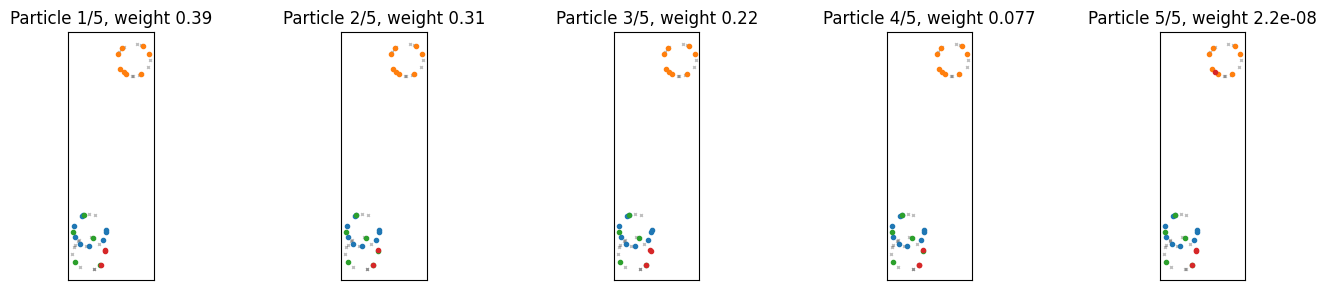

 50%|███████████████               | 28/56 [00:51<00:43,  1.56s/it, Particles=5]

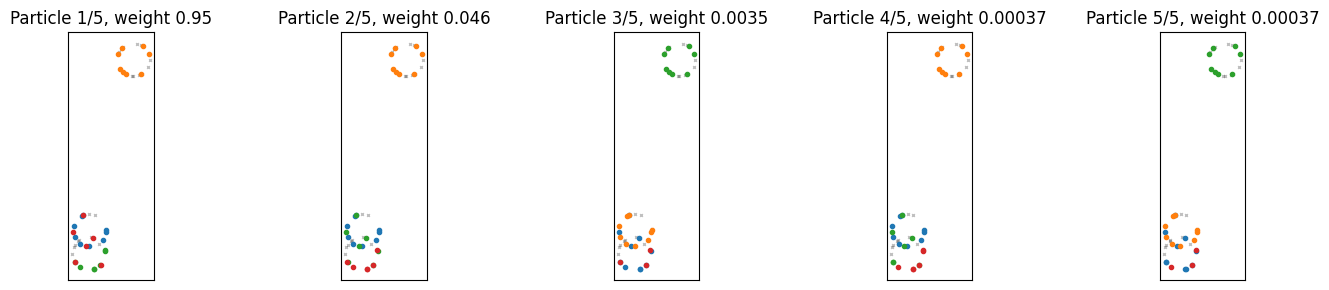

 59%|█████████████████▋            | 33/56 [00:59<00:35,  1.54s/it, Particles=5]

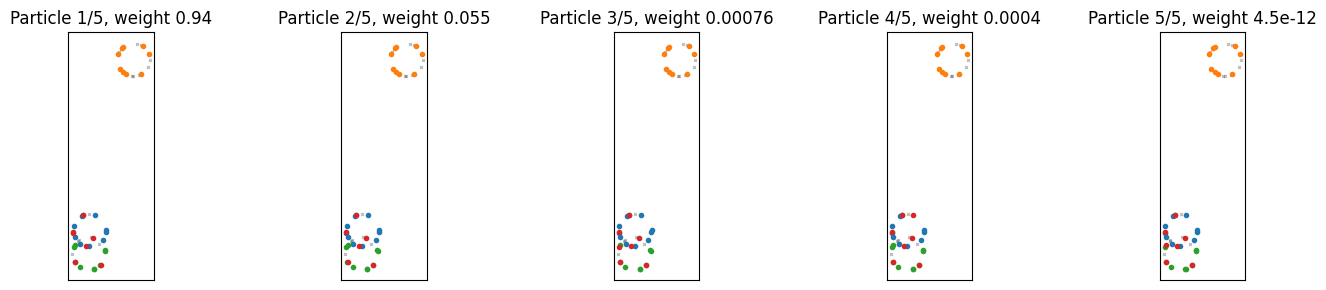

 68%|████████████████████▎         | 38/56 [01:08<00:28,  1.59s/it, Particles=5]

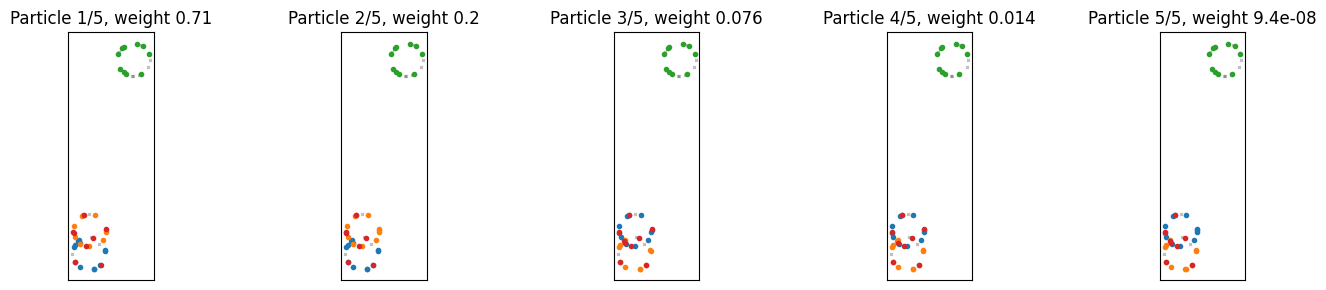

 77%|███████████████████████       | 43/56 [01:16<00:20,  1.60s/it, Particles=5]

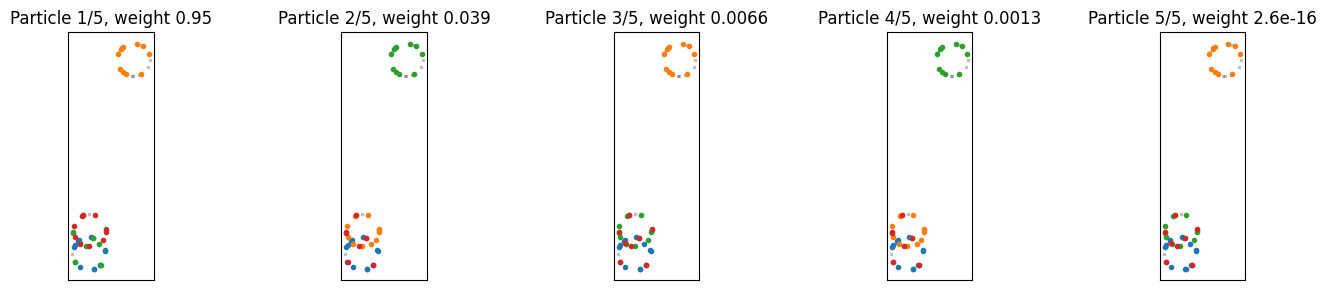

 86%|█████████████████████████▋    | 48/56 [01:24<00:12,  1.59s/it, Particles=5]

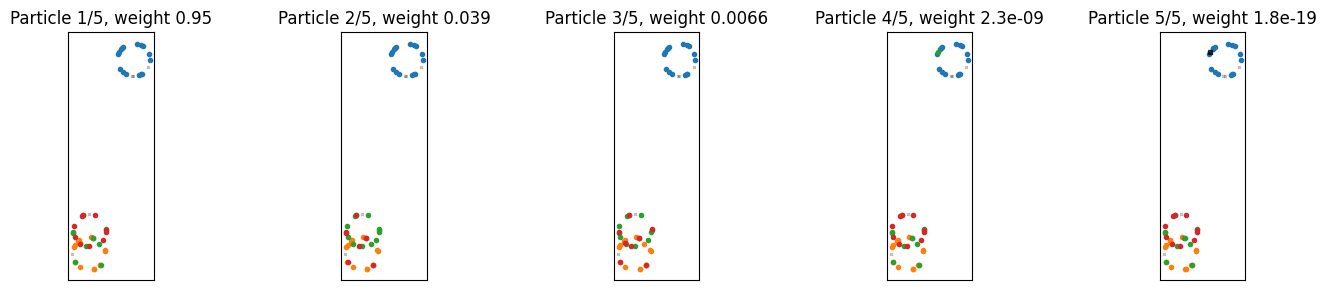

 95%|████████████████████████████▍ | 53/56 [01:38<00:06,  2.26s/it, Particles=5]

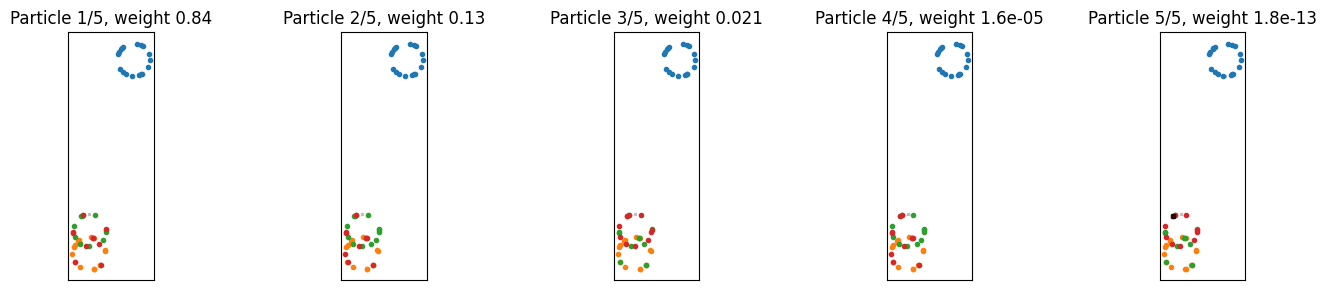

100%|██████████████████████████████| 56/56 [01:42<00:00,  1.83s/it, Particles=5]

In [5]:
num_time_steps = 100
def score_func(rng, data, masks):
    scores, _ = model.log_prob_ode(rng, data, masks, num_time_steps=num_time_steps)
    return scores

rng = jax.random.PRNGKey(1)
clusterer = SMCClusterer(data=cluster_data, score_fn=score_func, max_particles=5, resample_fn = resample_optimal, alpha=0.2)
clusterer.cluster(rng, plots=5)

In [6]:
clusterer.summary()

Particle 0, weight 0.97, 4 clusters, 57 points, [19, 14, 14, 10]
Particle 1, weight 0.028, 4 clusters, 57 points, [19, 16, 12, 10]
Particle 2, weight 2.7e-06, 4 clusters, 57 points, [19, 14, 13, 11]
Particle 3, weight 8.1e-07, 4 clusters, 57 points, [19, 16, 12, 10]
Particle 4, weight 2.9e-19, 4 clusters, 57 points, [19, 16, 11, 11]


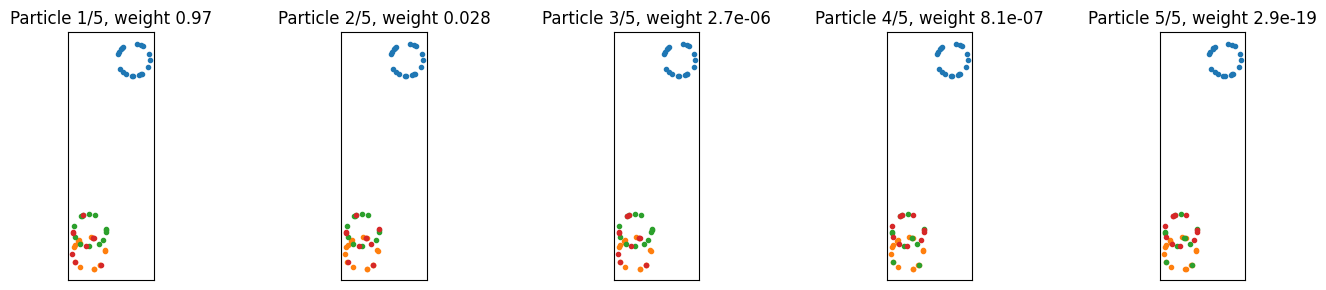

In [7]:
clusterer.plot_particles()

Compare to previous clusterer.

iteration 0, linking score: 21.9091
iteration 0, 56 clusters, 57 points, [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 1, linking score: 18.8735
iteration 1, 55 clusters, 57 points, [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 2, linking score: 15.5321
iteration 2, 54 clusters, 57 points, [2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 3, linking score: 15.3129
iteration 3, 53 clusters, 57 points, [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 4, linking score: 16.2744
iteration 4, 5

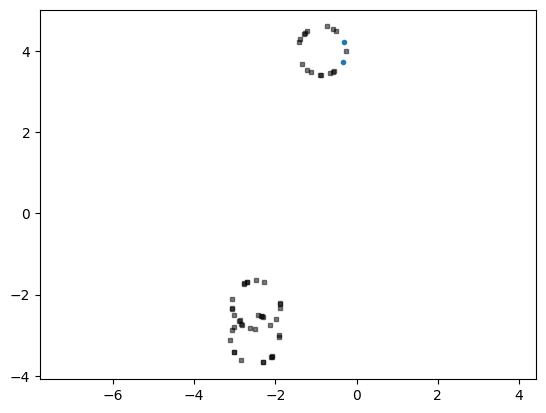

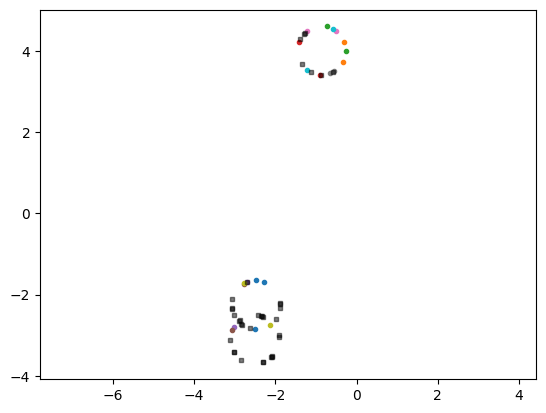

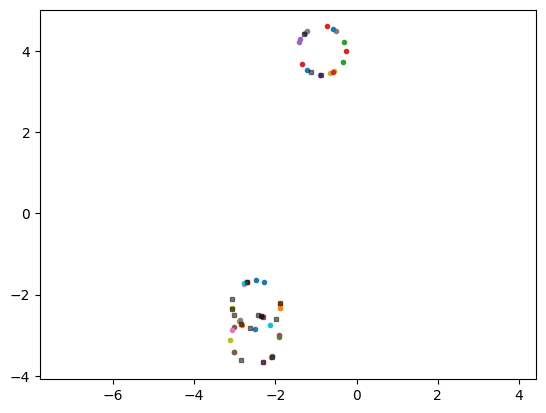

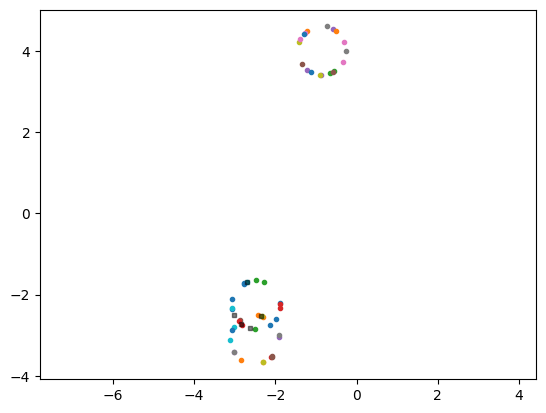

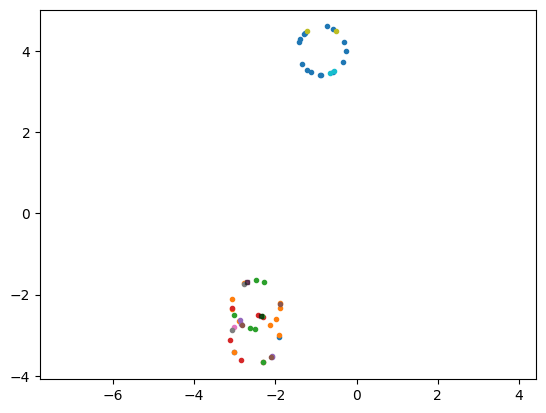

In [8]:
from diffusion_linking.jax.clustering import Clusterer

def plot_callback(clusters, iteration):
    # sort clusters by size
    clusters = sorted(clusters, key=lambda c: c.size, reverse=True)
    if iteration % 10 == 0:
        plt.figure()
        for c in clusters:
            if c.size > 1:
                plt.plot(c.data[:, 0], c.data[:, 1], 'o', markersize=3)
            else:
                plt.plot(c.data[:, 0], c.data[:, 1], 'ks', markersize=3, alpha=0.5)
        plt.axis('equal')

    print(
        f"iteration {iteration}, {len(clusters)} clusters, {sum([c.size for c in clusters])} points, {[c.size for c in clusters]}")

rng = jax.random.PRNGKey(1)
clusterer2 = Clusterer(data=cluster_data, score_fn=score_func, cluster_batch_size=16, link_threshold=0, batch_shape=(16,16))
t = time.time()
clusterer2.cluster(rng, max_iter=100, verbose=True, callback=plot_callback)
print(time.time()-t)

iteration 0, 7 clusters, 57 points, [17, 15, 8, 7, 5, 3, 2]


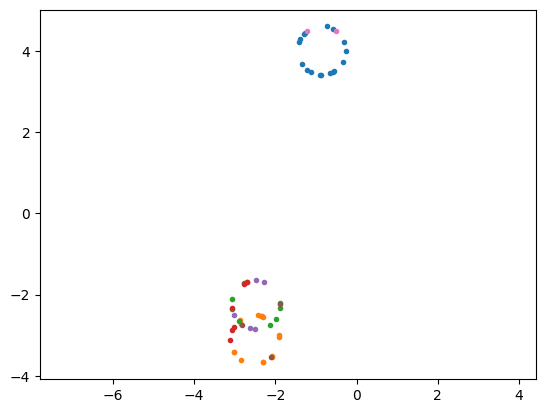

In [9]:
plot_callback(clusterer2.clusters, 0)